Some preliminaries to load the libraries for running experiments

In [1]:
# autoload
%load_ext autoreload
%autoreload 2

# import necessary libraries
import numpy as np

# Load PGL libraries and start a PGL window
from pgl import pgl, pglTask, pglExperiment, pglParameter, pglParameterBlock, pglTestTask
pgl = pgl()

# close any existing windows
pgl.cleanUp()

================================ pglBase: init =================================
(pgl) mglMetal error log can be viewed in MacOS Console app by searching for PROCESS mglMetal or in a terminal with:
      log stream --level info --process mglMetal
(pgl) To search for something specifc, e.g. messages from mglMovie:
      log stream --predicate 'eventMessage CONTAINS "mglMovie"' --style syslog --level info
(pgl:checkOS) Python version: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:35:20) [Clang 16.0.6 ]
(pgl:checkOS) Running on MacBook Pro (MacBookPro18,3) with macOS version: 26.3.1
(pgl:checkOS) Apple M1 Pro Cores: 8 (6 Performance and 2 Efficiency) Memory: 32 GB
(pgl:checkOS) GPU: Apple M1 Pro (Built-In) 14 cores, Metal 4 support
(pgl:checkOS)   Color LCD [Main Display]: 3024 x 1964 Retina (Built-in Liquid Retina XDR Display) GammaTable size: 1024
(pgl:checkOS)   LED Cinema Display: 1920 x 1200 (WUXGA - Widescreen Ultra eXtended Graphics Array) (Unknown type) GammaTable size

Next we define some monitor settings.

You should set the following in the dialog that comes up:

1. *Set **settingsName** to psycho*: this will then be the name that can be used to load these settings
2. *Set **displayName** to your main display* (e.g. something like Color LCD: Built-in Liquid Retina XDR Display): This will be the screen for which the experiment will be run (our other options are a windowed display for testing, or if you have mulitple monitors to use a 2nd display)
3. *Set **displayDistance** to 57*: This is in cm, the distance to the display that you should sit at. Normally we would measure this carefully so that we can make sure that stimuli are displayed correctly in degrees of visual angle. Here we use 57 because it turns out that at 57 cm, one degree of visual angle is roughly one cm on the screen which makes it easier to debug.
4. *Set **displayWidth** to 32*: Also in cm. Used for computing degrees of visual angle, this would be measured but for here, this should be close enough.
5. *Set **displayHeight** to 18*: Also in cm. 
6. *Set **dataPath** to "~/Desktop"*: This will make the data files save to your Desktop. You can then easily delete them once we are done with the tutorial.

After setting, click the "Test settings" button (read the following before you do that thought). It should open the screen full screen so you will not be able to see these instructions anymore. You should always be able to hit the "ESC" key to close the screen. If the test works, it will ask you to hit "space". Go ahead and do that and it should put up a bullseye pattern which should show rings with different degrees of visual angle. You should see something like +-15 degrees in x and +-7.5 in y. Hit Esc to close.

If everything worked then click "Save settings" and click "Yes" to confirm.


In [2]:
pgl.settings()

(pglExperiment) No settings provided, using default settings.


Box(children=(Box(children=(Dropdown(description='settingsNames', layout=Layout(width='100%'), options=('Main'…

Box(children=(Box(children=(Text(value='Main', description='settingsName', layout=Layout(width='100%'), style=…

Here we define the task whcih is run by the experiment. It defines how each trial is structured (into segments like fixation, stimulus display and response), what the parameters of the experiment are (e.g. motion coherences to test) what to draw on the screen, and how to handle subject responses.

In [ ]:
class pglDetectionTask(pglTask):
    
    ########################
    # Init
    ########################
    def __init__(self, pgl):
        super().__init__(pgl)
        
        # set task name
        self.settings.taskName = "Random Dot Motion Task"
        
        # How long each segment of a trial should run for in seconds.
        # Here we have 3 segments of a trial: fixation, stimulus, response
        self.settings.seglen = [0.5, 0.2, 1.5]
        
        # Number of trials to run for
        self.settings.nTrials = 5
        
        # Fixed parameters.
        self.settings.fixedParameters = {
            'width':15,
            'height':10,
            'coherence':(0.5,0),
            'dir':np.arange(0,360,45)
        }        
        p = self.settings.fixedParameters

        # Create parameters, which will have randomized values for each trial.
        # Note that we take the range of coherence and direction values from the fixed parameters
        coherence = pglParameter('coherence',p['coherence'])
        dir = pglParameter('dir',p['dir'])
        self.addParameter(pglParameterBlock([dir, coherence]))
        
        # initalize stimulus, note that width and height are in degrees of visual angle
        self.rdk = pgl.randomDots(width=p['width'], height=p['height'])
        
        # initialize data for subject responses and reaction times
        self.data.reactionTime = []
        self.data.presentAbsent = []
        self.data.subjectResponse = []

    ########################
    # Start segment
    ########################
    def startSegment(self, startTime):
        # call super 
        super().startSegment(startTime)
        
        # set some values back to default values on first segment
        if self.state.currentSegment==0:
            # (re)set fixation color to white
            self.state.fixationColor = [1, 1, 1]
            # no response recorded yet
            self.state.gotResponse = False
            self.state.response = None
            # set whether this is a present or absent trial
            if self.currentParams['coherence'] > 0:
                self.data.presentAbsent.append(1)
            else:
                self.data.presentAbsent.append(0)
                    
        elif self.state.currentSegment==1:
            # start of stimulus segment, record segment start time
            self.state.stimulusOnsetTime = startTime

    ########################
    # End trial
    ########################
    def endTrial(self, endTime):

        # record subject response
        self.data.subjectResponse.append(self.state.response)

    ########################
    # handleSubjectResponse
    ########################
    def handleSubjectResponse(self, responses, updateTime):
        # already received a response
        if self.state.gotResponse: return None

        # only allow responses during the stimulus and response segments
        if self.state.currentSegment>=1:
            # got the response
            self.state.gotResponse = True
            # record reaction time
            self.data.reactionTime.append(self.pgl.getSecs() - self.state.stimulusOnsetTime)
            # get subject response
            self.state.response = responses
            # get correct or incorrect
            self.state.correct = 1 if (self.state.response==0) and (self.data.presentAbsent[-1]==1) else 0
            # change fixation color to green or red depending on whether the subject response was correct
            self.state.fixationColor = [0.0, 1.0, 0.0] if self.state.correct else [1.0, 0.0, 0.0]
            # return correct or incorrect
            return self.state.correct

    ########################
    # Update screen
    ########################
    def updateScreen(self):
        # what to display on the segment depends on what segment of the trial we are in
        if self.state.currentSegment==1:
            # for the stimulus segment, display the random dot kinematogram with the current parameters
            self.rdk.display(direction=self.currentParams['dir'], coherence=self.currentParams['coherence'], speed=5.0)
        
        # block the part of the stimulus that would overlap with the fixation cross
        pgl.circle(radius=0.5, color=0.5, fill=True)
        # display a fixation cross
        pgl.fixationCross(color=self.state.fixationColor)





Here we create an experiment, attach the task defined above, and run the experiment. Note that it will automatically save the data at the end of the run.

In [ ]:
# Set up experiment
e = pglExperiment(pgl, "psycho", experimentName="detectionTask")
e.initScreen()

# add the task
detectionTask = pglDetectionTask(pgl)
e.addTask(detectionTask)

# and run the experiment
e.run()

(pglSettingsManager:loadSettings) Loading settings from '/Users/justin/.pgl/settings/psycho.json'.
================================= pglBase:open =================================
(pglBase:open) Starting mglMetal application: /Users/justin/Library/Developer/Xcode/DerivedData/Build/Products/Release/mglMetal.app
(pglBase:open) Using socket with address: /Users/justin/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260325_124638.PkQky1qCgl
(pgl:_pglComm) .Connected to: /Users/justin/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260325_124638.PkQky1qCgl
(pgl:_resolution:getResolution) Display 0/2: 1512x982 120Hz 32bits
(pglKeyboardMouse:start) Starting keyboard and mouse event listener.
(pglEventListener) Eating 7 keys: [18, 19, 20, 21, 49, 50, 53]
(pglExperiment:startPhase) Starting phase: 1/1
(Random Dot Motion Task) Trial 1: (pglExperiment:run) Experiment started.
(Random Dot Motion Task) Trial 2: (Random Dot Motion Task) Trial 3: (Random Dot Motion Task) Trial 4: (Rando

Now, let's load the data from the experiment that was run

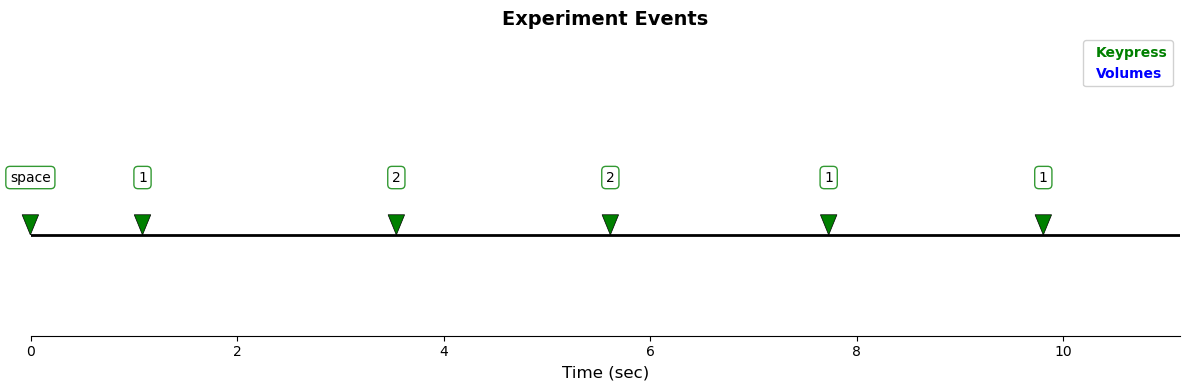

Trial Event 0: start
Trial Event 1: start
Trial Event 2: start
Trial Event 3: start
Trial Event 4: start
Trial Event 5: start
Trial Event 5: end
Trial Event 5: end
Trial Event 0: start
Trial Event 1: start
Trial Event 2: start
Trial Event 3: start
Trial Event 4: start
Trial Event 5: start
Trial Event 5: end
Trial Event 5: end


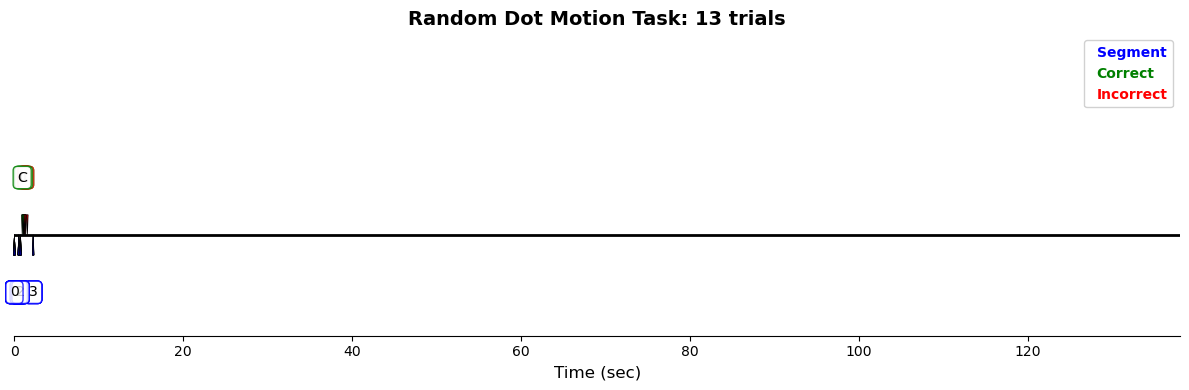

In [21]:
#e.load("detectionTask")
e.display()